# Table4U API: Restaurant Stay Duration Prediction

**Context:** This notebook develops a predictive system to estimate how long a person will stay in a restaurant. By analyzing features like party size, time of day, and day of the week, the model predicts the duration of the visit in minutes. This can help the restaurant optimize table turnover and improve customer service.

**Explanation:** Importing required libraries for data manipulation, visualization, and modeling.

In [ ]:
import warnings

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
import sklearn.metrics as metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

**Explanation:** Installing necessary packages for our environment.

In [ ]:
!pip install featuretools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.9/587.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 16.6 MB/s eta 0:00:00


**Explanation:** Installing necessary packages for our environment.

In [ ]:
!pip install xgboost

**Explanation:** Loading the dataset into a pandas DataFrame for analysis.

In [ ]:
df = pd.read_excel("dataset_previsao_duracao_10k.xlsx")

**Explanation:** Exploring the dataset to understand its structure, shape, and basic statistical properties.

In [ ]:
df.head()

,ID,Num_Pessoas,Check_in,Check_out,Duracao_Minutos
0,1,7,2025-08-10 10:52:00,2025-08-10 13:02:15.600,130.26000
1,2,4,2025-06-07 10:58:00,2025-06-07 12:20:42.600,82.71000
2,3,8,2025-05-02 18:06:00,2025-05-02 20:07:42.000,121.70000
3,4,5,2025-02-18 16:08:00,2025-02-18 17:32:16.800,84.28000
4,5,7,2025-10-24 17:12:00,2025-10-24 18:51:48.000,99.80000


**Explanation:** Exploring the dataset to understand its structure, shape, and basic statistical properties.

In [ ]:

df["Check_in"] = pd.to_datetime(df["Check_in"])
df["Check_out"] = pd.to_datetime(df["Check_out"])

df.head()

,ID,Num_Pessoas,Check_in,Check_out,Duracao_Minutos
0,1,7,2025-08-10 10:52:00,2025-08-10 13:02:15.600,130.26000
1,2,4,2025-06-07 10:58:00,2025-06-07 12:20:42.600,82.71000
2,3,8,2025-05-02 18:06:00,2025-05-02 20:07:42.000,121.70000
3,4,5,2025-02-18 16:08:00,2025-02-18 17:32:16.800,84.28000
4,5,7,2025-10-24 17:12:00,2025-10-24 18:51:48.000,99.80000


**Explanation:** Using Featuretools to automatically generate new features based on the relationships in the data.

In [ ]:
import featuretools as ft

es = ft.EntitySet(id="restaurante")

es = es.add_dataframe(
    dataframe_name="visitas",
    dataframe=df,
    index="ID",
    time_index="Check_in"
)

**Explanation:** Using Featuretools to automatically generate new features based on the relationships in the data.

In [ ]:
feature_matrix, feature_defs = ft.dfs(
    entityset=es,
    target_dataframe_name="visitas",
    max_depth=2,
    verbose=True
)

Built 10 features
Elapsed: 00:00 | Progress: 100%|██████████


**Explanation:** Executing data processing and modeling steps.

In [ ]:
feature_matrix["hora"] = df["Check_in"].dt.hour
feature_matrix["dia_semana"] = df["Check_in"].dt.weekday
feature_matrix["mes"] = df["Check_in"].dt.month
feature_matrix["fim_de_semana"] = feature_matrix["dia_semana"].isin([5,6]).astype(int)

**Explanation:** Plotting data trends, such as average duration by hour, to understand user behavior patterns.

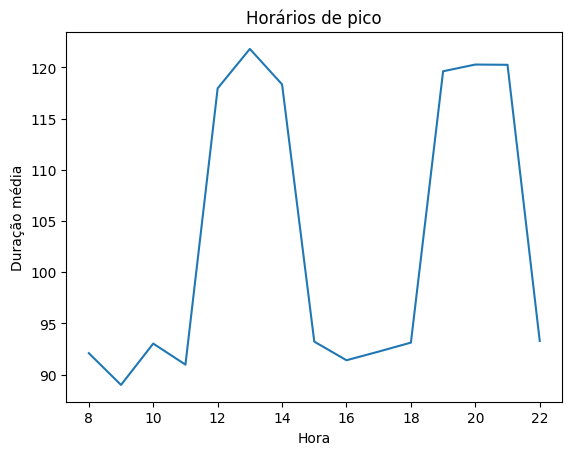

In [ ]:
import matplotlib.pyplot as plt

picos = df.groupby(df["Check_in"].dt.hour)["Duracao_Minutos"].mean()

plt.plot(picos)
plt.xlabel("Hora")
plt.ylabel("Duração média")
plt.title("Horários de pico")
plt.show()

**Explanation:** Engineering a custom 'period' feature based on the time of day (e.g., lunch, dinner).

In [ ]:
def periodo(h):
    if 11 <= h <= 14:
        return "almoco"
    elif 18 <= h <= 21:
        return "jantar"
    else:
        return "normal"

feature_matrix["periodo"] = feature_matrix["hora"].apply(periodo)

**Explanation:** Executing data processing and modeling steps.

In [ ]:
feature_matrix.head()

,Num_Pessoas,Duracao_Minutos,DAY(Check_in),DAY(Check_out),MONTH(Check_in),MONTH(Check_out),WEEKDAY(Check_in),WEEKDAY(Check_out),YEAR(Check_in),YEAR(Check_out),hora,dia_semana,mes,fim_de_semana,periodo
ID,,,,,,,,,,,,,,,
6167,1,29.72000,1,1,1,1,2,2,2025,2025,8,2,1,0,normal
9220,5,89.57000,1,1,1,1,2,2,2025,2025,9,2,1,0,normal
50,8,112.65000,1,1,1,1,2,2,2025,2025,10,2,1,0,normal
2559,10,146.74000,1,1,1,1,2,2,2025,2025,10,2,1,0,normal
9752,1,36.90000,1,1,1,1,2,2,2025,2025,10,2,1,0,normal


**Explanation:** Removing unnecessary columns that were generated or are no longer needed for modeling.

In [ ]:
cols_remover = [
    "DAY(Check_out)",
    "MONTH(Check_out)",
    "WEEKDAY(Check_out)",
    "YEAR(Check_out)"
]

feature_matrix = feature_matrix.drop(columns=cols_remover)

**Explanation:** Removing unnecessary columns that were generated or are no longer needed for modeling.

In [ ]:
X = feature_matrix.drop(columns=["Duracao_Minutos"])
y = feature_matrix["Duracao_Minutos"]

**Explanation:** Importing required libraries for data manipulation, visualization, and modeling.

In [ ]:
import pandas as pd

X = pd.get_dummies(X)

**Explanation:** Splitting the data into training and validation sets to evaluate the model's generalization.

In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor()
model.fit(X_train, y_train)

print("Score:", model.score(X_test, y_test))

Score: 0.9856762220095356


**Explanation:** Calculating the Root Mean Squared Error (RMSE) to measure the regression model's performance.

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 5.4384548309202385


**Explanation:** Importing required libraries for data manipulation, visualization, and modeling.

In [ ]:
import pandas as pd

exemplo = {
    "Num_Pessoas": 6,
    "hora": 13,
    "dia_semana": 2,
    "mes": 8,
    "fim_de_semana": 0,
    "periodo": "almoco",

    # manter consistência com featuretools
    "DAY(Check_in)": 10,
    "MONTH(Check_in)": 8,
    "WEEKDAY(Check_in)": 2,
    "YEAR(Check_in)": 2025
}

df_exemplo = pd.DataFrame([exemplo])

**Explanation:** One-hot encoding categorical variables to convert them into a numerical format suitable for the model.

In [ ]:
df_exemplo = pd.get_dummies(df_exemplo)

# alinhar colunas com treino
df_exemplo = df_exemplo.reindex(columns=X.columns, fill_value=0)

**Explanation:** Generating the final prediction for the sample data point.

In [ ]:
pred = model.predict(df_exemplo)

print("Tempo previsto (min):", pred[0])

Tempo previsto (min): 120.45502


**Explanation:** Persisting the trained model and its expected features to disk for future inference.

In [ ]:
import joblib

joblib.dump(model, "modelo_xgboost.pkl")
joblib.dump(X.columns, "colunas.pkl")

['colunas.pkl']